In [1]:
using Distributed
addprocs(10)
@everywhere include("1_timed_old_proc.jl")

In [3]:
A, tim = @timed pmap(rangeexp, 1:10)
tim

9.0322092

In [4]:
A[25]

(Float32[1.0 0.99959093 … 0.9732729 0.9668654; 1.0 0.99947923 … 0.9586244 0.9613587; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0], Int32[109 102 … 105 96; 96 99 … 104 91; … ; 0 0 … 0 0; 0 0 … 0 0])

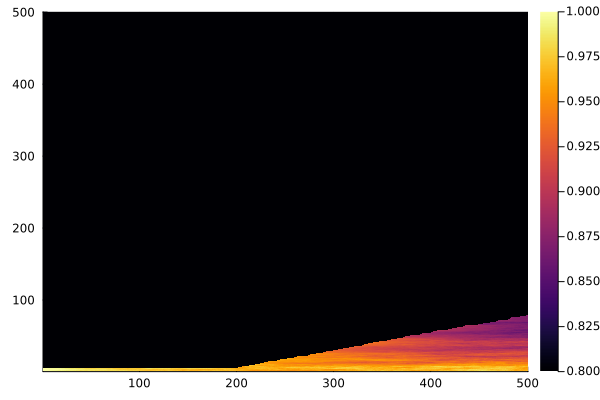

In [4]:
using Plots
heatmap(A[4],clim=(0.8,1.0))

In [5]:
@show A[5][:,end]

(A[5])[:, end] = Float32[0.9923758, 0.9955822, 0.97939193, 0.9848368, 0.97996944, 0.9692928, 0.95303434, 0.95499045, 0.94988346, 0.95303875, 0.9497659, 0.9386581, 0.94253165, 0.9313697, 0.91866803, 0.94011235, 0.9423296, 0.9392738, 0.93975794, 0.95390177, 0.94111377, 0.93474597, 0.92686254, 0.9278746, 0.93455625, 0.92555964, 0.924376, 0.92501515, 0.92748773, 0.9240711, 0.9143871, 0.92784053, 0.933393, 0.92462194, 0.9314973, 0.92581123, 0.9107446, 0.9112698, 0.9205391, 0.9202714, 0.9151519, 0.9177977, 0.92188954, 0.9236457, 0.9255439, 0.9301327, 0.9240105, 0.9283871, 0.9310182, 0.93133533, 0.9368258, 0.94016343, 0.9308599, 0.9282687, 0.9288903, 0.931786, 0.933434, 0.93034136, 0.93536264, 0.9314921, 0.93017447, 0.9316044, 0.930088, 0.9272173, 0.92403454, 0.9140828, 0.93283767, 0.9346588, 0.94100344, 0.9362693, 0.9356935, 0.93078196, 0.93320346, 0.9317401, 0.9347731, 0.93459153, 0.93059707, 0.93764454, 0.93779755, 0.93987316, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.

500-element Vector{Float32}:
  0.9923758
  0.9955822
  0.97939193
  0.9848368
  0.97996944
  0.9692928
  0.95303434
  0.95499045
  0.94988346
  0.95303875
  ⋮
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0

In [14]:
indicess = [findlast(x -> x >= 0, A[j]) for j in 1:25]
last_valid_index = mean(ci.I[1] for ci in indicess)

81.36

In [15]:
using Statistics

stacked = cat(A...; dims=3)
avg = mapslices(x -> mean(filter(!=(-1.0), x)), stacked; dims=3)[:, :, 1]


500×500 Matrix{Float32}:
   1.0    0.999631    0.999184  …    0.977164    0.977443    0.977848
   1.0    0.999596    0.999237       0.977002    0.976605    0.977401
   1.0    0.99961     0.999213       0.976263    0.976575    0.977424
   1.0    0.999618    0.99922        0.976573    0.976877    0.97718
   1.0    0.999655    0.999206       0.978221    0.978201    0.97807
 NaN    NaN         NaN         …    0.971488    0.97157     0.971656
 NaN    NaN         NaN              0.965829    0.965819    0.965365
 NaN    NaN         NaN              0.959336    0.960414    0.960341
 NaN    NaN         NaN              0.951788    0.952716    0.953334
 NaN    NaN         NaN              0.947937    0.948698    0.948448
   ⋮                            ⋱                          
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN     

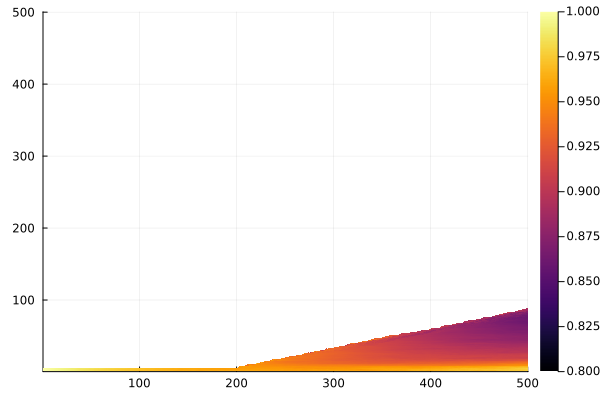

In [17]:
using Plots
heatmap(avg,clim=(0.8,1.0))

In [16]:
avg[findlast(x -> !isnan(x), avg)]

0.8910243f0

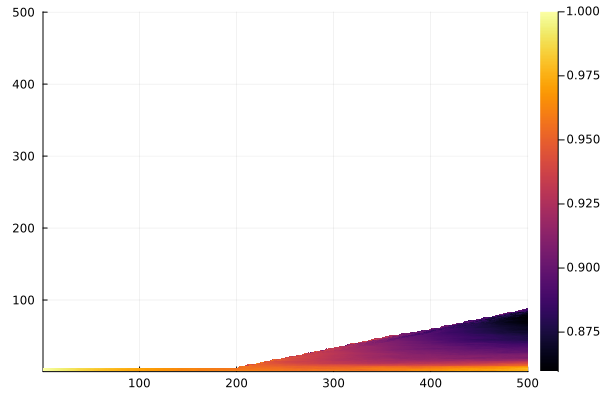

In [18]:
heatmap(avg)

---

In [1]:
using Distributed
addprocs(15)
@everywhere include("1_timed_old_proc.jl")
# Turn on pops_out for this

In [2]:
A, tim = @timed pmap(rangeexp, 1:15)
tim

9.41847

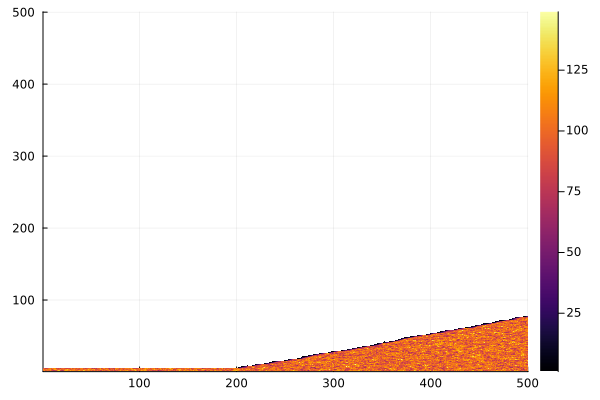

In [3]:
using Plots
heatmap(replace(A[1][2], 0.0 => NaN))

---

In [1]:
include("1_timed_old_proc.jl")

rangeexp (generic function with 2 methods)

In [2]:
A1 = rangeexp()

Int16[93, 103, 96, 91, 100, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 

500×1 Matrix{Float32}:
  1.0
  1.0
  1.0
  1.0
  1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
  ⋮
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0